In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
# data_df=pd.read_csv('..\\data\\pca_results.csv')
data_df=pd.read_csv('..\\..\\data\\dataset_7_18.csv')
# data_df=pd.read_csv('..\\data\\pca_results.csv')
# sample_train=pd.DataFrame({'filler': [ 0.04, 0.03,0.05], 'thickness（mm）': [0.08,0.1,0.07]})
# data_df=pd.concat([data_df,sample_train],ignore_index=True)
# data_df.at[len(data_df)-2,'new_PVA']=1
# data_df.at[len(data_df)-2,'new_PVA']=1
# data_df.at[len(data_df)-1,'new_PVA']=1
# data_df.fillna(0,inplace=True)



In [3]:
X=data_df.drop(labels=['emi_cat'],axis=1)
Y=data_df['emi_cat']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# y_train.loc[X_train.loc[X_train['new_PVA']==1].index]

In [4]:

# rf_model = RandomForestClassifier(n_estimators=100, random_state=50)
gb_model = GradientBoostingClassifier(n_estimators=100 ,random_state=42)
# logi_mode=LogisticRegression(random_state=42,solver='lbfgs',max_iter=10000,multi_class='auto',)
# MLP_model=MLPClassifier(solver='lbfgs',random_state=42,hidden_layer_sizes=(20,),max_iter=1000,activation='relu',learning_rate_init=0.01)

# rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
# MLP_model.fit(X_train, y_train)
# rf_score=rf_model.score(X_test, y_test)
gb_score=gb_model.score(X_test,y_test)
# mlp_score=MLP_model.score(X_test, y_test)

# logi_mode.fit(X_train, y_train)

# print("随机森林模型,rf_model.score:", rf_score)
print("梯度提升树模,gb_model.score:", gb_score)
# print("MLP模型,mlp_model.score:", mlp_score)

y_pred = gb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logi Accuracy: {accuracy}")

# 将分类报告转换为DataFrame并显示为表格
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\n分类评估报告:")
print("=" * 60)
print(df_report.to_string())
print("=" * 60)


梯度提升树模,gb_model.score: 0.8181818181818182
Logi Accuracy: 0.8181818181818182

分类评估报告:
              precision    recall  f1-score    support
0.0            0.909091  0.714286  0.800000  14.000000
1.0            0.807692  0.933333  0.865979  45.000000
2.0            0.785714  0.611111  0.687500  18.000000
accuracy       0.818182  0.818182  0.818182   0.818182
macro avg      0.834166  0.752910  0.784493  77.000000
weighted avg   0.820991  0.818182  0.812261  77.000000


In [12]:
#训练集上的分类报告
y_pred_on_trainset = gb_model.predict(X_train)
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Logi Accuracy: {accuracy}")

# 将分类报告转换为DataFrame并显示为表格
report = classification_report(y_train, y_pred_on_trainset, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\nGBT在训练集上的分类评估报告:")
print("=" * 60)
print(df_report.to_string())
print("=" * 60)


GBT在训练集上的分类评估报告:
              precision    recall  f1-score     support
0.0            0.975610  0.851064  0.909091   47.000000
1.0            0.886792  0.994709  0.937656  189.000000
2.0            0.980769  0.739130  0.842975   69.000000
accuracy       0.914754  0.914754  0.914754    0.914754
macro avg      0.947724  0.861634  0.896574  305.000000
weighted avg   0.921739  0.914754  0.911834  305.000000


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResMLPBlock(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(dim, hidden_dim)
        # self.relu=F.relu()
        self.linear2 = nn.Linear(hidden_dim, dim)
        # self.norm = nn.LayerNorm(dim)
        # self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        residual = x
        # x = self.norm(x)
        x = F.relu(self.linear1(x))
        # x = self.dropout(x)
        x = self.linear2(x)
        # x = self.dropout(x)
        return x + residual

class ResMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_blocks=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.Sequential(*[
            ResMLPBlock(hidden_dim, hidden_dim*4, dropout)
            for _ in range(num_blocks)
        ])
        # self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, num_classes)
        # self.soft = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        # x = self.norm(x)
        return self.head(x)

In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    best_acc = 0.89
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    epoch_results = []

    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证阶段
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        epoch_results.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })

        # 保存最佳模型
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            
        
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}', end='\r')
    
    results_df = pd.DataFrame(epoch_results)
    results_df.to_csv('g:\\VScode\\Mxene-7-12\\src\\training_log.csv', index=False)
    print("\nTraining log saved to g:\\VScode\\Mxene-7-12\\src\\training_log.csv")
    
    # 绘制训练曲线
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.title('Loss Curve')
    
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.show()
    
    return model

In [6]:
def prepare_data(X_train, y_train, X_test, y_test, batch_size=32):
    # 转换为PyTorch张量
    X_train_tensor = torch.FloatTensor(X_train.values)
    y_train_tensor = torch.LongTensor(y_train.values)
    X_test_tensor = torch.FloatTensor(X_test.values)
    y_test_tensor = torch.LongTensor(y_test.values)
    
    # 创建数据集
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
    
    # 创建数据加载器
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)
    
    return train_loader, test_loader

Epoch 300/300: Train Loss: 0.1710, Train Acc: 0.9279 | Val Loss: 0.6770, Val Acc: 0.8571
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


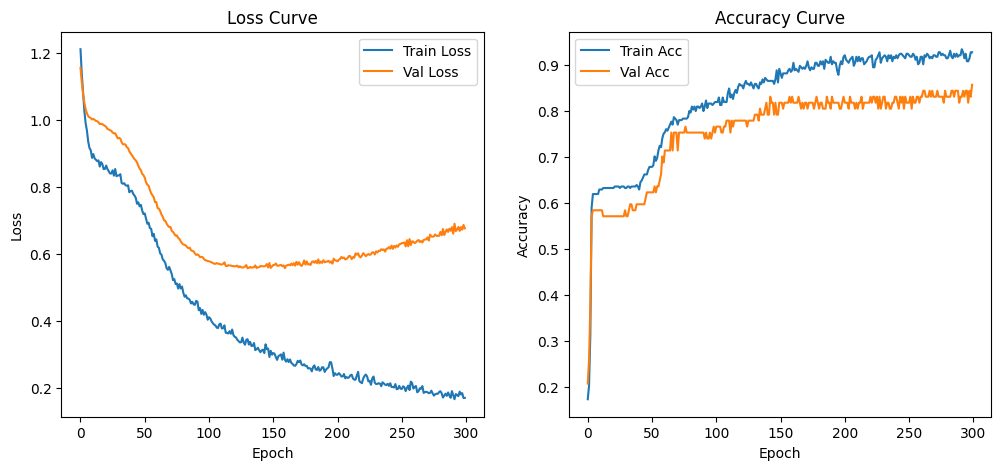

Epoch 300/300: Train Loss: 0.1644, Train Acc: 0.9279 | Val Loss: 0.7850, Val Acc: 0.8571
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


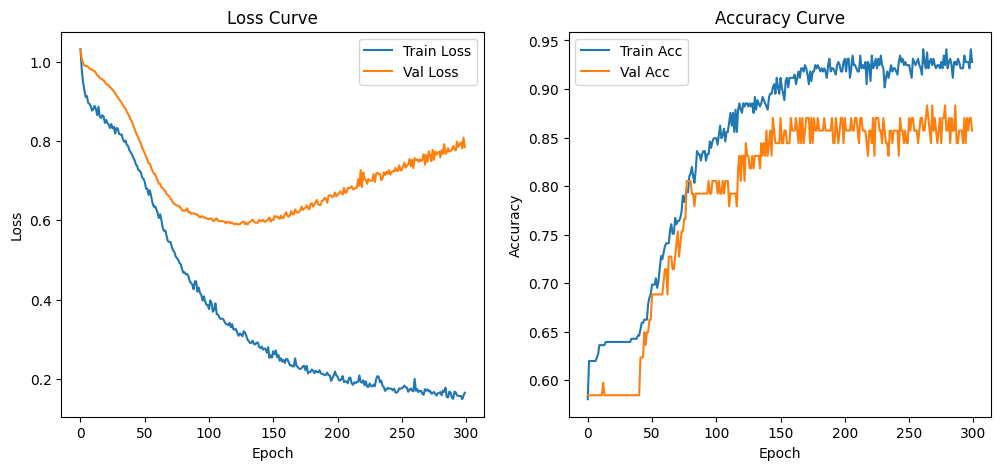

Epoch 300/300: Train Loss: 0.1527, Train Acc: 0.9410 | Val Loss: 0.9609, Val Acc: 0.8312
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


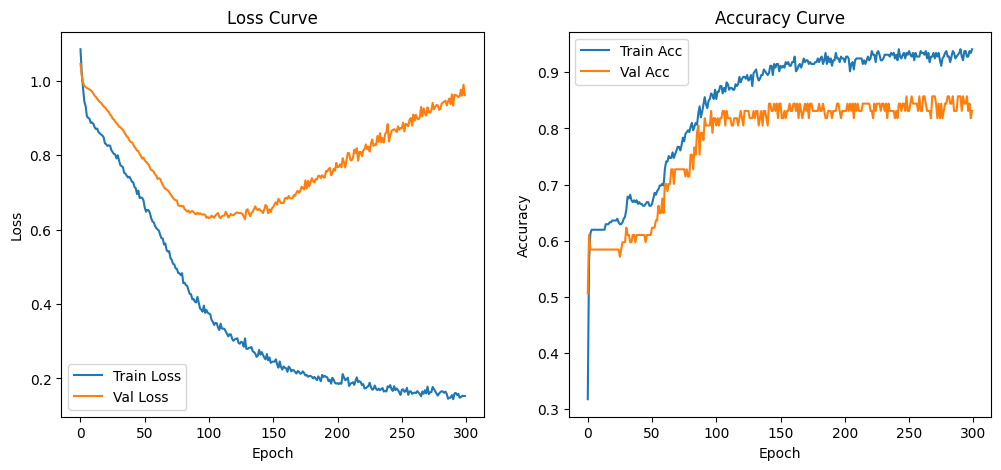

Epoch 300/300: Train Loss: 0.1775, Train Acc: 0.9246 | Val Loss: 0.9307, Val Acc: 0.8442
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


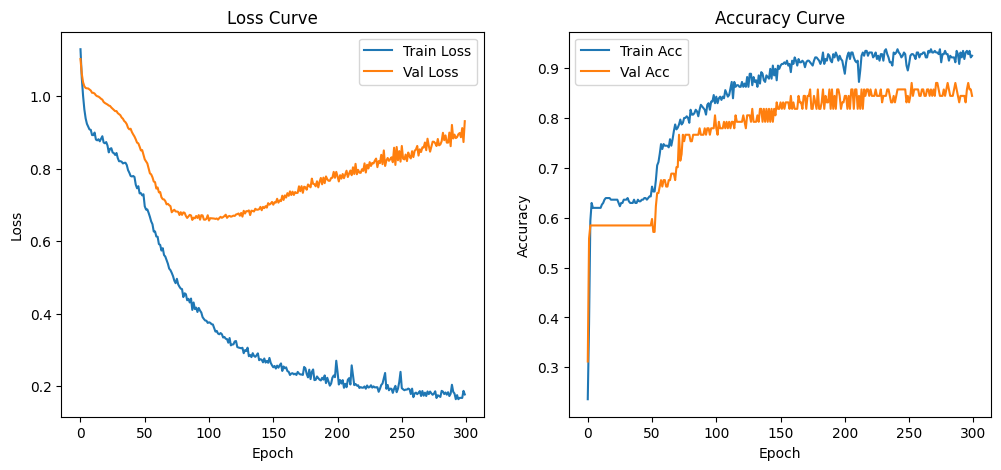

Epoch 300/300: Train Loss: 0.2011, Train Acc: 0.9344 | Val Loss: 0.7393, Val Acc: 0.8312
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


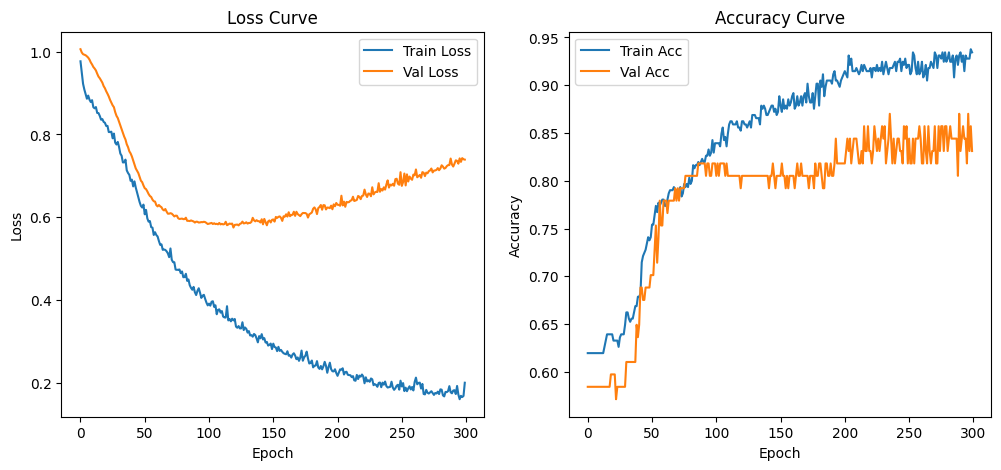

Epoch 300/300: Train Loss: 0.1775, Train Acc: 0.9180 | Val Loss: 0.7129, Val Acc: 0.8312
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


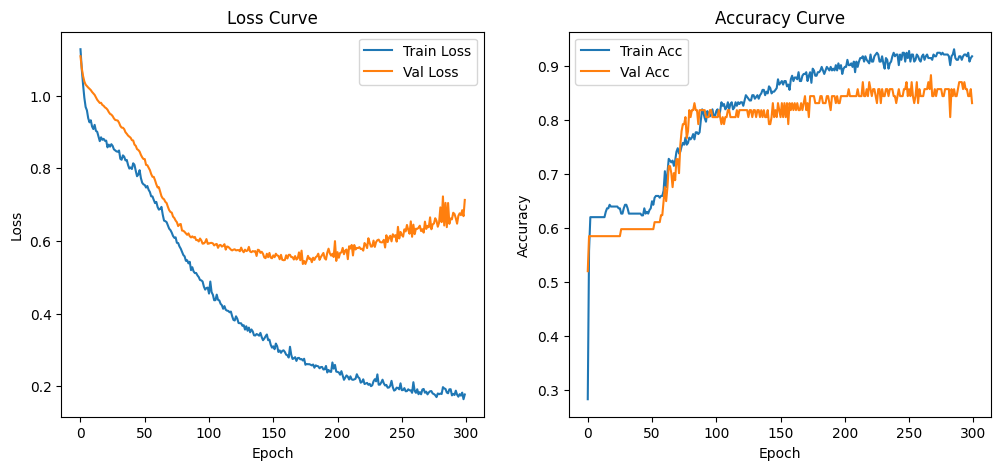

Epoch 300/300: Train Loss: 0.1850, Train Acc: 0.9180 | Val Loss: 0.7286, Val Acc: 0.8442
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


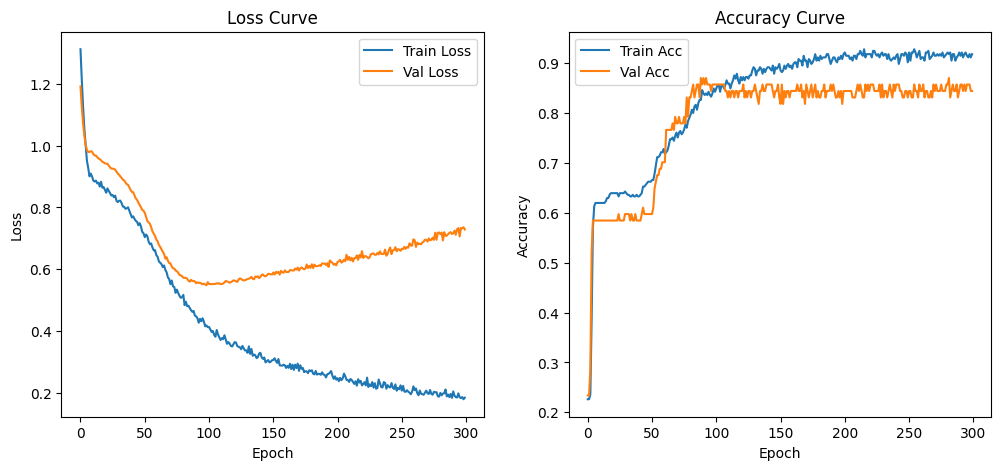

Epoch 300/300: Train Loss: 0.1552, Train Acc: 0.9344 | Val Loss: 0.7522, Val Acc: 0.8701
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


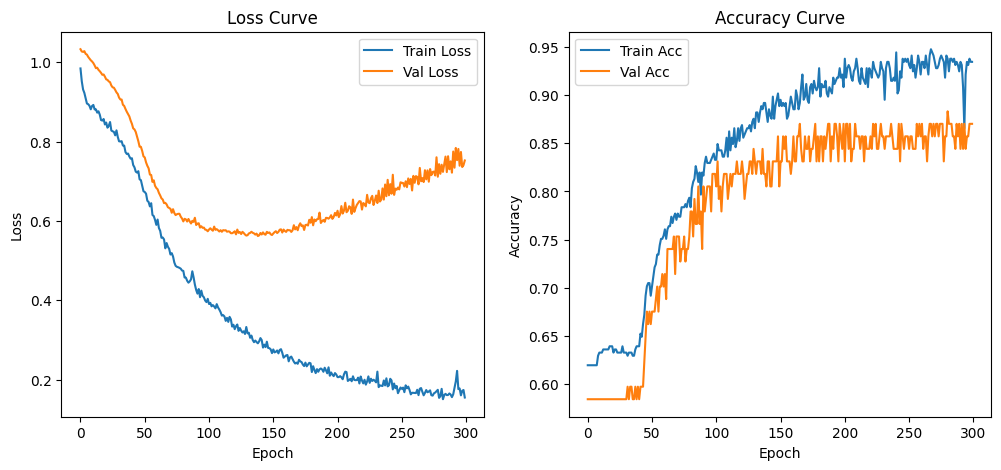

Epoch 300/300: Train Loss: 0.1823, Train Acc: 0.9279 | Val Loss: 0.7606, Val Acc: 0.8312
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


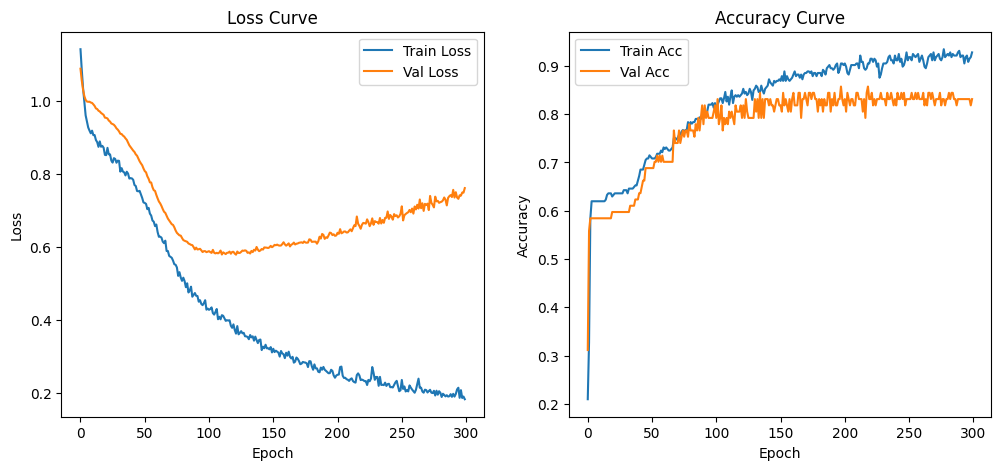

Epoch 300/300: Train Loss: 0.1927, Train Acc: 0.9213 | Val Loss: 0.7751, Val Acc: 0.8442
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


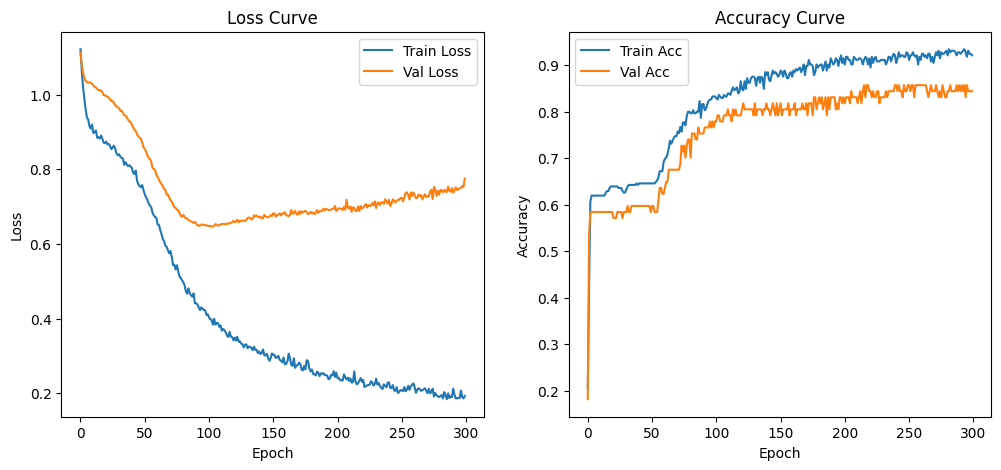

Epoch 300/300: Train Loss: 0.1935, Train Acc: 0.9082 | Val Loss: 0.6517, Val Acc: 0.8701
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


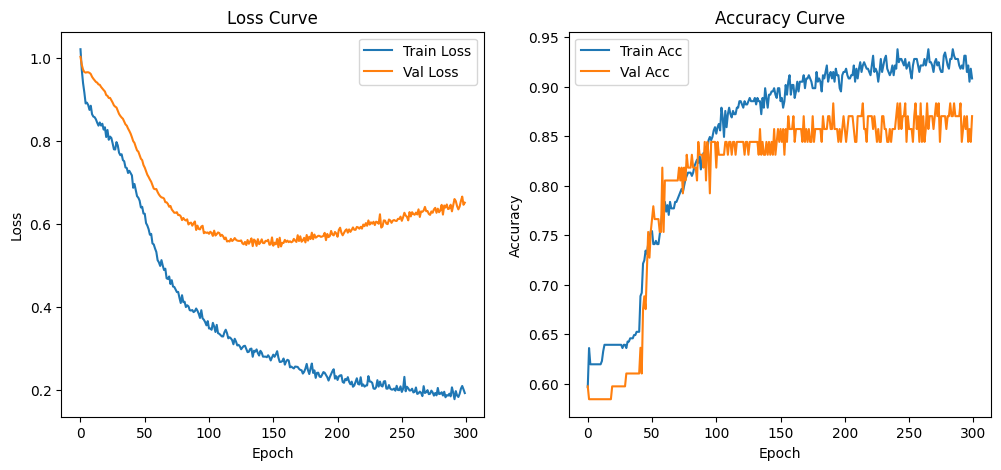

Epoch 300/300: Train Loss: 0.1707, Train Acc: 0.9246 | Val Loss: 0.8613, Val Acc: 0.8571
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


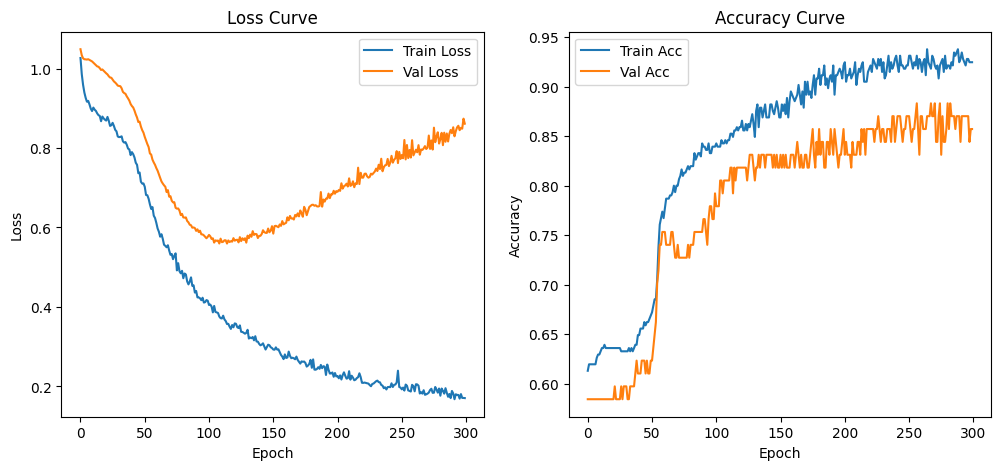

Epoch 300/300: Train Loss: 0.1801, Train Acc: 0.9246 | Val Loss: 0.6636, Val Acc: 0.8701
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


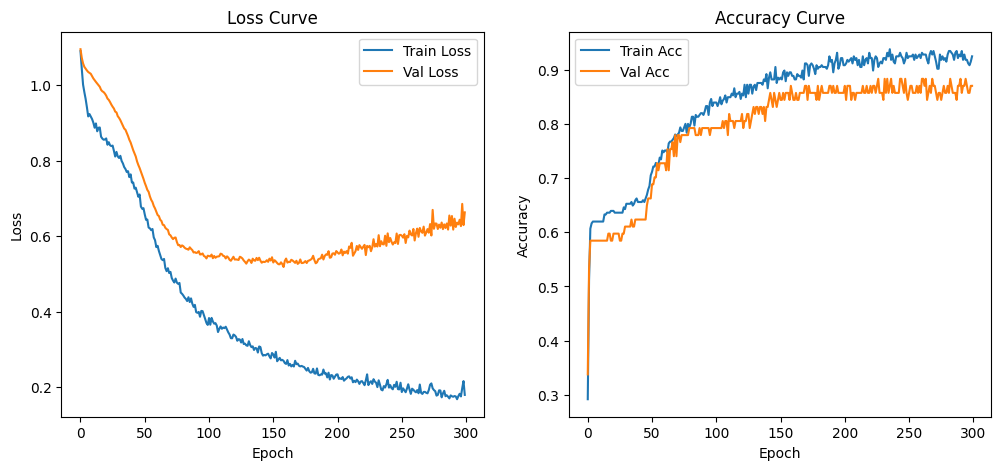

Epoch 300/300: Train Loss: 0.1679, Train Acc: 0.9148 | Val Loss: 0.7320, Val Acc: 0.8831
Training log saved to g:\VScode\Mxene-7-12\src\training_log.csv


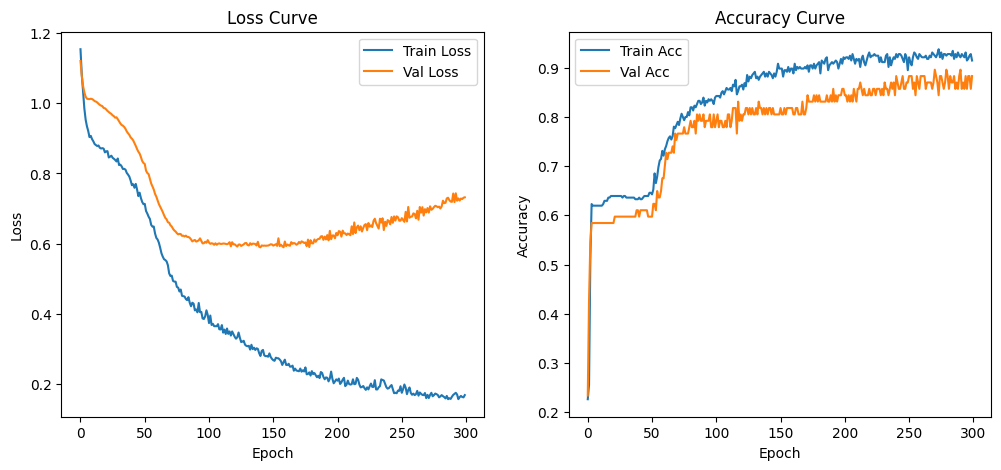

In [23]:
train_loader, test_loader = prepare_data(X_train, y_train, X_test, y_test)
import os
while True:    
    # 初始化模型
    model = ResMLP(input_dim=X_train.shape[1], 
                    hidden_dim=40, 
                    num_classes=len(y_train.unique()),
                    num_blocks=20)
        
        # 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000015)
        
    # 训练模型

    trained_model = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=300)
    if os.path.exists('./best_model.pth'):
        break

In [16]:
#生成预测和分类报告
resmlp_save.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = resmlp_save(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# 构建分类报告
target_names = ['类别0 (<20dB)', '类别1 (20-50dB)', '类别2 (>50dB)']
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=target_names,
    digits=3
)

print("ResMLP分类报告:")
print(report)

ResMLP分类报告:
               precision    recall  f1-score   support

  类别0 (<20dB)      0.857     0.857     0.857        14
类别1 (20-50dB)      0.894     0.933     0.913        45
  类别2 (>50dB)      0.938     0.833     0.882        18

     accuracy                          0.896        77
    macro avg      0.896     0.875     0.884        77
 weighted avg      0.897     0.896     0.896        77



In [7]:
# model = ResMLP(input_dim=X_train.shape[1],
#                     hidden_dim=40,
#                     num_classes=len(y_train.unique()),
#                     num_blocks=20)

##读取模型.pth
criterion = nn.CrossEntropyLoss()

train_loader, test_loader = prepare_data(X_train, y_train, X_test, y_test)
resmlp_save=ResMLP(input_dim=X_train.shape[1],
                  hidden_dim=40,
                  num_classes=len(y_train.unique()),
                  num_blocks=20)
resmlp_save.load_state_dict(torch.load('best_model.pth'))
# optimizer = torch.optim.Adam(resmlp_save.parameters(), lr=0.000015)

resmlp_save.eval()
val_running_loss = 0.0
val_correct = 0
val_total = 0
val_losses = []
val_accs = []
with torch.no_grad():
    for inputs, labels in train_loader:
        inputs, labels = inputs.to('cpu'), labels.to('cpu')
        outputs = resmlp_save(inputs)
        loss = criterion(outputs, labels)
        
        val_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / len(train_loader)
val_acc = val_correct / val_total
val_losses.append(val_loss)
val_accs.append(val_acc)
print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

Validation Loss: 0.1577, Validation Accuracy: 0.9344


In [9]:
## 获取resmlp在训练集上的分类报告
def evaluate_on_train_set(model, train_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in train_loader:
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    print("\n=== ResMLP Training Set Classification Report ===")
    target_names = ['类别0 (<20dB)', '类别1 (20-50dB)', '类别2 (>50dB)']
    report = classification_report(all_labels, all_preds, target_names=target_names, digits=3)
    print(report)

evaluate_on_train_set(resmlp_save,train_loader)


=== ResMLP Training Set Classification Report ===
               precision    recall  f1-score   support

  类别0 (<20dB)      0.913     0.894     0.903        47
类别1 (20-50dB)      0.947     0.952     0.950       189
  类别2 (>50dB)      0.913     0.913     0.913        69

     accuracy                          0.934       305
    macro avg      0.924     0.920     0.922       305
 weighted avg      0.934     0.934     0.934       305



In [151]:
plt.show()

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [2]:
X_test.columns

Index(['filler', 'thickness（mm）', 'CA', 'CNC', 'CS', 'Cellulose microspheres',
       'EPDM', 'GO', 'HEC', 'MMT', 'NR', 'PLA', 'PNFs', 'PNP', 'PPy', 'PS',
       'SiO2', 'carbon', 'cellulose', 'cotton fabrics', 'g-C3N4', 'graphene',
       'h-BN', 'natural rubber', 'nonwoven fabric', 'paraffin', 'polyurethane',
       'wax', 'wood', 'Ag', 'Co', 'MF', 'MWCNTs', 'NC', 'Ni', 'PMDI', 'PNIPAM',
       'PU', 'TiO2', 'WPU', 'melamine', 'film', 'foam', 'new_epoxy', 'new_PI',
       'new_TPU', 'new_PVA', 'new_PANI', 'new_PDMS', 'new_PEDOT:PSS',
       'new_PDA', 'new_PEG', 'new_Fe3O4', 'new_CFF', 'new_CNF', 'new_CNT',
       'new_PAN', 'new_AgNW', 'new_PVDF', 'new_rGO', 'new_SA', 'new_ANF'],
      dtype='object')

,filler,thickness（mm）,EMI_SE（SE/dB）,Ti3C2Tx,Mo2Ti2C3Tx,Mo2TiC2Tx,Nb2CTx,Ti2CTx,Ti3C2Tx,Ti3CNTx,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
0,0.900000,NaN,NaN,0.0,0.0,0.0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
1,0.800000,1.000,50.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2,NaN,1.000,17.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN
3,0.600000,1.000,10.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,0.900000,1.000,32.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,0.199951,0.030,8.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,...,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,1.0
488,0.399902,0.030,19.0,NaN,0.0,0.0,NaN,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0
489,0.500000,0.031,25.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
490,0.600098,0.040,36.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,filler,thickness（mm）,EMI_SE（SE/dB）,Ti3C2Tx,Mo2Ti2C3Tx,Mo2TiC2Tx,Nb2CTx,Ti2CTx,Ti3C2Tx,Ti3CNTx,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF


,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
268,0.320068,0.5000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
250,0.340088,0.0067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
355,0.899902,6.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
332,0.560059,0.1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56,0.830000,0.0400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0.300000,0.0330,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
167,0.199951,2.5000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
63,0.100000,0.1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
233,0.879883,0.0541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
X_test

,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
280,0.119995,0.2000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
248,0.270020,0.0067,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
218,0.059998,0.3000,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
327,0.140015,0.0700,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
56,0.830000,0.0400,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0.300000,0.0330,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
167,0.199951,2.5000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
63,0.100000,0.1000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
232,0.399902,0.0900,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
sample=pd.DataFrame({'filler': [0.047, 0.3, 0.25,0.8,0.4], 'thickness（mm）': [0.1,0.06,0.1,0.1,0.1]})
test_includ_sample=pd.concat([X_test, sample],ignore_index=True)
test_includ_sample.at[77,'new_PVA']=1
test_includ_sample.at[77,'film']=1
test_includ_sample.at[78,'new_CNF']=1
test_includ_sample.at[78,'film']=1
test_includ_sample.at[79,'graphene']=1
test_includ_sample.at[79,'film']=1
test_includ_sample.at[80,'new_CNF']=1
test_includ_sample.at[80,'film']=1
test_includ_sample.at[81,'new_PVA']=1
test_includ_sample.at[81,'film']=1
test_includ_sample=test_includ_sample.fillna(0)
test_includ_sample

,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
0,0.119995,0.2000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.270020,0.0067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.059998,0.3000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.140015,0.0700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.830000,0.0400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,0.004700,0.1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0.300000,0.0600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79,0.250000,0.1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80,0.800000,0.1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
X_train.columns

Index(['filler', 'thickness（mm）', 'CA', 'CNC', 'CS', 'Cellulose microspheres',
       'EPDM', 'GO', 'HEC', 'MMT', 'NR', 'PLA', 'PNFs', 'PNP', 'PPy', 'PS',
       'SiO2', 'carbon', 'cellulose', 'cotton fabrics', 'g-C3N4', 'graphene',
       'h-BN', 'natural rubber', 'nonwoven fabric', 'paraffin', 'polyurethane',
       'wax', 'wood', 'Ag', 'Co', 'MF', 'MWCNTs', 'NC', 'Ni', 'PMDI', 'PNIPAM',
       'PU', 'TiO2', 'WPU', 'melamine', 'film', 'foam', 'new_epoxy', 'new_PI',
       'new_TPU', 'new_PVA', 'new_PANI', 'new_PDMS', 'new_PEDOT:PSS',
       'new_PDA', 'new_PEG', 'new_Fe3O4', 'new_CFF', 'new_CNF', 'new_CNT',
       'new_PAN', 'new_AgNW', 'new_PVDF', 'new_rGO', 'new_SA', 'new_ANF'],
      dtype='object')

In [26]:
X_test.loc[y_test[y_test==0].index]

,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
280,0.119995,0.200,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
118,0.009674,1.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
286,0.020004,0.300,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
365,1.000000,3.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
39,0.970000,0.030,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,0.400000,2.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
113,0.009148,0.248,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,0.400000,0.800,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,0.600000,0.800,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0.050000,2.000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
# y_train
# X_train[y_train==0].loc[X_train['new_CNF']==1]
test_includ_sample[-5:]

,filler,thickness（mm）,CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,MMT,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
77,0.0047,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0.3000,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79,0.2500,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80,0.8000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,0.4000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
y_prob=rf_model.predict(test_includ_sample[-5:])
y_prob

array([1., 0., 2., 1., 1.])

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


ValueError: multiclass format is not supported

C:\Users\IMP\AppData\Local\Temp\ipykernel_40184\1505741744.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature',


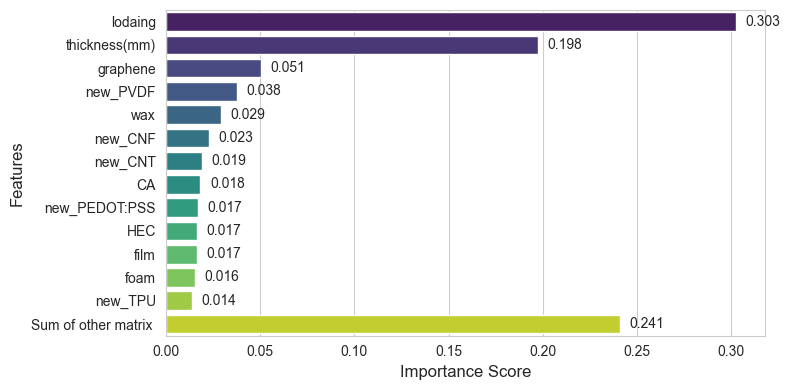

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
feature_importances = rf_model.feature_importances_
# 创建特征名列表
feature_names = list(X.columns)
# 创建一个DataFrame，包含特征名和其重要性得分
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
# 对特征重要性得分进行排序
feature_importances_df = feature_importances_df.sort_values('importance', ascending=True)
threshold = 0.014
important_features = feature_importances_df[feature_importances_df['importance'] > threshold]
other_features = feature_importances_df[feature_importances_df['importance'] <= threshold]

# 计算其他特征的总重要性
other_total = other_features['importance'].sum()

# 合并数据
plot_data = pd.concat([
    important_features.sort_values('importance', ascending=False),
    pd.DataFrame({'feature': ['Sum of other matrix '], 'importance': [other_total]})
])
# 颜色映射
# colors = plt.cm.rainbow(np.linspace(0, 1, len(feature_names)))####颜色可改YlGnBu、PuBu、viridis······

# 可视化特征重要性
#水平条形图
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))

ax = sns.barplot(x='importance', y='feature', 
                data=plot_data,
                palette="viridis",
                saturation=0.8)

# 设置标题和标签
# ax.set_title(f'Random Forest Feature Importances (Threshold={threshold})', fontsize=15, pad=20)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Features', fontsize=12)

# 添加数值标签
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.005, 
            p.get_y() + p.get_height()/2., 
            '{:1.3f}'.format(width),
            ha="left", 
            va="center",
            fontsize=10)

plt.tight_layout()
plt.savefig('g:\\VScode\\Mxene-7-12\\feature_importances_filtered.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\IMP\AppData\Local\Temp\ipykernel_40184\89388999.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(data=data_df, x='emi_cat', y='thickness(mm)',
C:\Users\IMP\AppData\Local\Temp\ipykernel_40184\89388999.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(data=data_df, x='emi_cat', y='thickness(mm)',


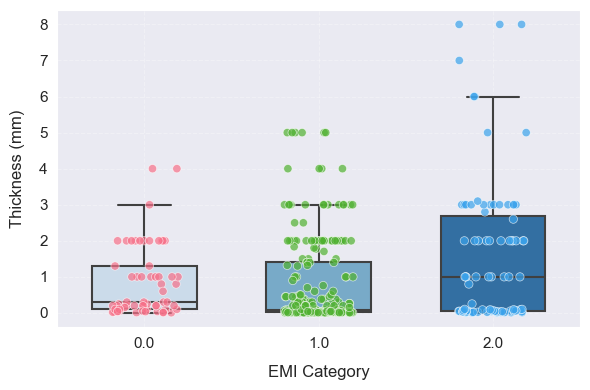

In [32]:
plt.figure(figsize=(6, 4), facecolor='white')

# 使用seaborn的深色主题
sns.set_style("darkgrid")

# 箱线图使用渐变色
box = sns.boxplot(data=data_df, x='emi_cat', y='thickness(mm)', 
                 palette="Blues", width=0.6,
                 linewidth=1.5, fliersize=0)

# 散点图使用对比色
strip = sns.stripplot(data=data_df, x='emi_cat', y='thickness(mm)',
                     palette="husl", alpha=0.7, jitter=0.2, 
                     size=6, edgecolor='white', linewidth=0.5)

# 美化标题和标签
# plt.title('Thickness Distribution by EMI Category', 
        #  fontsize=14, pad=12, fontweight='bold')
plt.xlabel('EMI Category', fontsize=12, labelpad=10)
plt.ylabel('Thickness (mm)', fontsize=12, labelpad=10)

# 调整坐标轴
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
# 保存图像
plt.savefig('g:\\VScode\\Mxene-7-12\\thickness_distribution_by_emi_category.svg',format='svg' )

C:\Users\IMP\AppData\Local\Temp\ipykernel_40184\1714992638.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(data=data_df, x='emi_cat', y='lodaing',
C:\Users\IMP\AppData\Local\Temp\ipykernel_40184\1714992638.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(data=data_df, x='emi_cat', y='lodaing',


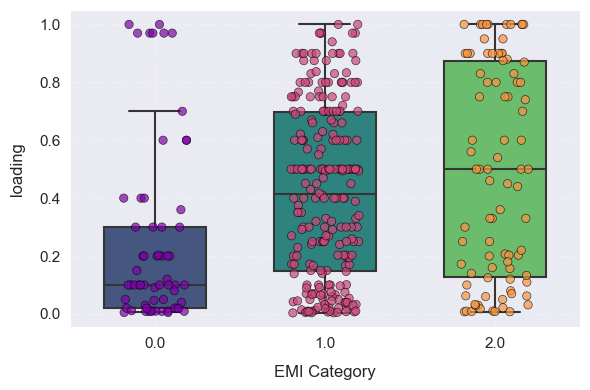

In [37]:
plt.figure(figsize=(6, 4), facecolor='white')

# 使用seaborn的深色主题
sns.set_style("darkgrid")

# 箱线图使用渐变色
box = sns.boxplot(data=data_df, x='emi_cat', y='lodaing', 
                 palette="viridis", width=0.6,
                 linewidth=1.5, fliersize=0)

# 散点图使用对比色
strip = sns.stripplot(data=data_df, x='emi_cat', y='lodaing',
                     palette="plasma", alpha=0.7, jitter=0.2, 
                     size=6, edgecolor='black', linewidth=0.5)

# 美化标题和标签
# plt.title('Thickness Distribution by EMI Category', 
        #  fontsize=14, pad=12, fontweight='bold')
plt.xlabel('EMI Category', fontsize=12, labelpad=10)
plt.ylabel('loading', fontsize=12, labelpad=10)

# 调整坐标轴
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
# 保存图像
plt.savefig('g:\\VScode\\Mxene-7-12\\loading_distribution_by_emi_category.svg',format='svg' )

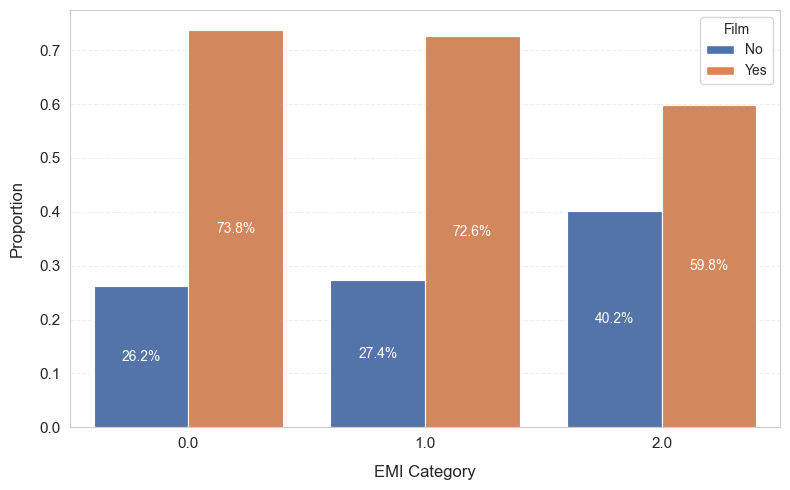

In [44]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

# 计算比例并转换为长格式
ct = pd.crosstab(data_df['emi_cat'], data_df['film'], normalize='index').stack().reset_index(name='proportion')

# 使用Seaborn绘制堆叠条形图
ax = sns.barplot(data=ct, x='emi_cat', y='proportion', hue='film',
                palette=['#4c72b0', '#dd8452'],  # 专业配色方案
                edgecolor='white', linewidth=0.8,
                saturation=0.85)

# 美化图形元素
# plt.title('Film Distribution by EMI Category', 
#          fontsize=14, pad=12, fontweight='semibold')
# 自定义图例项
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4c72b0', label='No'),
    Patch(facecolor='#dd8452', label='Yes')
]
plt.legend(handles=legend_elements, title='Film')
plt.xlabel('EMI Category', fontsize=12, labelpad=10)
plt.ylabel('Proportion', fontsize=12, labelpad=10)
# plt.legend(title='Film', labels=['No', 'Yes'], 
#           frameon=True, framealpha=0.8)

# 优化坐标轴和网格
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)  # 网格线在条形下方
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 添加数值标签
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2.,
                p.get_y() + height/2,
                f'{height:.1%}',
                ha='center', va='center',
                fontsize=10, color='white')

plt.tight_layout()
plt.savefig('g:\\VScode\\Mxene-7-12\\film_distribution_by_emi_category.svg',format='svg')

In [ ]:
##特征总结
import seaborn as sns

X_20=data_df[data_df['emi_cat']==0]
# y_20=X_20['emi_cat']
# X_20_train=X_20.drop(labels=['emi_cat'],axis=1)
# 
X_20_50=data_df[data_df['emi_cat']==1]
# y_20_50=X_20_50['emi_cat']
# X_20_50_train=X_20_50.drop(labels=['emi_cat'],axis=1)

X_50=data_df[data_df['emi_cat']==2]
# y_50=X_50['emi_cat']
# X_50_train=X_50.drop(labels=['emi_cat'],axis=1)


In [ ]:

print(len(X_20))
sns.displot(X_20, x="filler", binwidth=0.2)

print(len(X_20_50))
sns.displot(X_20_50, x="filler", binwidth=0.2)

print(len(X_50))
sns.displot(X_50, x="filler", binwidth=0.2)

In [ ]:

sns.catplot(X_20, x="film",kind="box",hue='foam')

sns.displot(X_20_50, x="film")

sns.displot(X_50, x="film")

In [ ]:

sns.catplot(X_20.drop(labels=['filler','film','foam'],axis=1), x=X_20.drop(labels=['filler','film','foam'],axis=1))

# sns.catplot(X_20_50, x="film")

# sns.catplot(X_50, x="film")

--- 

In [ ]:
import pandas as pd
data_root='..\\data\\data_500_pro.csv'
data_df=pd.read_csv(data_root)

data_df.columns
data_df['Ti3C2Tx']=data_df['Ti3C2Tx']+data_df[' Ti3C2Tx']
data_df['TiO2']=data_df[' TiO2']+data_df['TiO2']
data_df['new_CNT']=data_df['CNTs']+data_df['new_CNT']
data_df['new_CNF']=data_df['CNFs']+data_df['new_CNF']
data_df['new_AgNW']=data_df['AgNWs']+data_df['new_AgNW']

non_ti3c2=[' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx']
del_nont3c2=[]
for i in non_ti3c2:
    for idx, item in enumerate(data_df[i]):
        if item==1:
            del_nont3c2.append(idx)
data_df_drop=data_df.drop(labels=del_nont3c2,axis=0)
for i in data_df_drop['Mo2Ti2C3Tx']:
    if i == 1:
        print('false')
        break
    
data_df_drop.drop(columns=['Unnamed: 0','Conductivity（S/m）',' Ti3C2Tx','Mo2Ti2C3Tx','Mo2TiC2Tx','Nb2CTx','Ti2CTx','Ti3CNTx','Ti3C2Tx',' TiO2','CNTs','CNFs'
                           ,'AgNWs'],inplace=True)

data_df_drop.reset_index(drop=True,inplace=True)
data_df_drop

In [ ]:
for idx, item in enumerate(data_df_drop['EMI_SE（SE/dB）']):
    if item <20:
        data_df_drop.at[idx,'emi_cat']=0
    if item >=20 and item <50:
        data_df_drop.at[idx,'emi_cat']=1
    if item >=50:
        data_df_drop.at[idx,'emi_cat']=2

In [ ]:
data_df_drop.info()

In [ ]:
from random import sample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

del_epoch=range(20)
SAVE=True
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
logi_mode=LogisticRegression(random_state=42,solver='lbfgs',max_iter=1000,multi_class='auto',)

while SAVE:
    data_df=data_df_drop

    X=data_df.drop(labels=['emi_cat'],axis=1)
    Y=data_df['emi_cat']

    for i in del_epoch:
        # if len(X)<400: break
        print(f'X 数据集长度：{len(X)}')
        X=X.reset_index(drop=True)
        Y=Y.reset_index(drop=True)
        random_state=sample(range(100),1)[0]
        X_train, X_test, y_train, y_test = train_test_split(X.drop('EMI_SE（SE/dB）',axis=1), Y, test_size=0.4, random_state=42)
        
        
        rf_model.fit(X_train, y_train)
        gb_model.fit(X_train, y_train)
        rf_score=rf_model.score(X_test, y_test)
        gb_score=gb_model.score(X_test,y_test)

        logi_mode.fit(X_train, y_train)

        print("随机森林模型,rf_model.score:", rf_score)
        print("梯度提升树模,gb_model.score:", gb_score)
        print(f"Logi Accuracy: {logi_mode.score(X_test, y_test)}")
        print('----------------------------------------------------------------------------')
        if rf_score > 0.9 :
            save_df=pd.concat([X,Y,],axis=1)
            save_df.to_csv('save_df.csv',index=False)
            SAVE=False
            break
        y_pred = rf_model.predict(X_test)
        err_list=[]
        i=0
        while i < len(y_test):
            if y_pred[i] != y_test.values[i]:
                
                err_list.append(y_test.index[i])
            i+=1
        
        X=X.drop(labels=sample(err_list,int(len(err_list)*0.4)),axis=0)
        Y=Y.drop(labels=sample(err_list,int(len(err_list)*0.4)),axis=0)
        # accuracy = accuracy_score(y_test, y_pred)
        


    # print(classification_report(y_test, y_pred))
    print(random_state)

In [ ]:
import pandas as pd
data=pd.read_csv('../save_df1.csv')
data

In [2]:
# sns.boxplot(data=data.iloc[:,2:],y='EMI_SE(SE/dB)')
data_20=data[data['emi_cat']==0]
data_20_50=data[data['emi_cat']==1]
data_50=data[data['emi_cat']==2]

In [42]:
classes=[data_20_train,data_20_50_train,data_50_train]
for item in classes:
    item=item.loc[:, (item != 0).any(axis=0)]
    item.reset_index(drop=True,inplace=True)
    # if item:
        # item.drop(labels='emi_cat',axis=1,inplace=True)

In [ ]:
data_20_50.drop(labels=['emi_cat'],axis=1,inplace=True)
data_50.drop(labels=['emi_cat'],axis=1,inplace=True)

In [ ]:
import seaborn as sns
import matplotlib.pyplot  as plt
plt.figure(figsize=(20,10))
plt.xticks(rotation=90)
sns.boxplot(data=data_20_50,x='material',y='filler',hue='material',legend=False)

In [ ]:
sns.displot(data=data_20,y='EMI_SE(SE/dB)',x='thickness(mm)',hue='filler')

In [ ]:
# data_20_decode=pd.DataFrame(index=data_20.index,columns=['EMI_SE(SE/dB)'])

for item in classes:
    columns=item.columns[3:]
    item.reset_index(drop=True,inplace=True)

    for i in item.index:
        material=''
        for col in columns:
            
            if item.loc[i,col]==1 and col!='film' and col!='foam': 
                material=material+col+"+"
                
        item.at[i,'material']=material
        if item.loc[i,'film']==1:
            item.at[i,'structure']='film'
        else:
            item.at[i,'structure']='foam'
        

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.xticks(rotation=90)
# plt.title('EMI<20 and filler')
sns.boxplot(data=data_20_50,x='material',y='EMI_SE(SE/dB)',hue='material')

In [ ]:
plt.figure(figsize=(20,10))
plt.xticks(rotation=90)
sns.histplot(data=data_50,x='material',hue='material')

In [ ]:
data_20_50['material']

In [ ]:
data_50_train.loc[data_50_train['material']=='wood+']

In [ ]:
data_50.loc[data_50['material']=='CNC+WPU+']

In [ ]:

    
sns.boxplot(data=data_20,x='structure',y='EMI_SE(SE/dB)',hue='structure')


In [ ]:
sns.histplot(data=data_20,x='structure',y='EMI_SE(SE/dB)',hue='structure')

In [ ]:
sns.scatterplot(data=data_20,x='filler',y='EMI_SE(SE/dB)')

In [ ]:
sns.scatterplot(data=data_20,x='thickness(mm)',y='EMI_SE(SE/dB)')

In [ ]:
sns.histplot(data=data_20,x='filler',y='EMI_SE(SE/dB)',hue='foam')

In [ ]:
import matplotlib.pyplot as plt

# 创建一个示例的DataFrame
data_20_drop=data_20.drop(labels=['filler','thickness(mm)',],axis=1)
# 使用melt函数将one-hot编码的变量转换成两列: variable和value
melted_df = pd.melt(data_20_drop, id_vars=['EMI_SE(SE/dB)'], value_vars=['film','foam'],var_name='Sturcture')
plt.figure(figsize=(10,10))
# 使用catplot函数画出每个one-hot变量与target变量的箱线图
sns.catplot(x='value',y='EMI_SE(SE/dB)', kind='box', data=melted_df)


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
data_df=pd.read_csv('../save_df1.csv')

X=data_df.drop(labels=['emi_cat'],axis=1)
Y=data_df['emi_cat']
# pca=PCA(n_components=)
# X=pca.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [4]:
# data_test=pd.concat([X_test,y_test],axis=1)
data_20_train=X_train[X_train.loc[:,'EMI_SE(SE/dB)']<20]
data_50_train=X_train[X_train.loc[:,'EMI_SE(SE/dB)']>50]
data_20_50_index=X_train[X_train.loc[:,'EMI_SE(SE/dB)']<=50]
data_20_50_train=data_20_50_index[data_20_50_index.loc[:,'EMI_SE(SE/dB)']>=20]
del data_20_50_index

In [5]:
X_test

,filler,thickness(mm),EMI_SE(SE/dB),CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
336,0.600098,2.000,21.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
307,0.202969,1.000,17.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
90,0.250000,3.000,104.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
265,0.549805,2.000,29.8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150,0.066992,0.380,32.7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,1.000000,0.018,50.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
137,0.009636,2.000,9.6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
357,0.090027,0.024,33.0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
168,0.600098,0.040,21.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [7]:
X_test.loc[X_test['new_CNF']==1 and ]

,filler,thickness(mm),EMI_SE(SE/dB),CA,CNC,CS,Cellulose microspheres,EPDM,GO,HEC,...,new_Fe3O4,new_CFF,new_CNF,new_CNT,new_PAN,new_AgNW,new_PVDF,new_rGO,new_SA,new_ANF
218,0.399902,0.019,24.94,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
284,0.005520,2.000,34.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
377,0.080017,0.600,35.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
22,0.500000,0.167,25.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
248,0.080017,0.047,28.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
375,0.040009,0.600,24.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
317,0.700195,0.100,30.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
358,0.270020,0.026,43.00,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
316,0.300049,0.100,11.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
355,0.750000,4.000,48.00,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
data_20=pd.DataFrame(index=data_20.index,columns=['EMI_SE(SE/dB)'])
for idx, item in enumerate(data_df['EMI_SE(SE/dB)']):
    if item<20:
        data_df.at[idx,'EMI_SE(SE/dB)']=0
    else:
        data_df.at[idx,'EMI_SE(SE/dB)']=1